# OTM-Only Heston Calibration — Experiment Sandbox

**Independent of the production pipeline.** This notebook reuses the project's data /
filtering / pricing functions, but implements its **own calibration universe selection**
and its **own calibration routine** in-notebook, so you can experiment without touching
`services/` or `calibration/`. If a variant works, the in-notebook code is written to be
production-portable.

What is different from `nvda_heston_pipeline.ipynb`:

1. **Two distinct universes.**
   - *Pricing/screening universe* — broad liquidity filter (existing `filter_chain_with_stats`).
   - *Calibration universe* — **tight, OTM-only**, built here with clearly exposed knobs.
2. **OTM-only selection** using the implied forward F(T):
   - `K < F`  -> keep the **OTM put**  (the call there is ITM -> skip)
   - `K > F`  -> keep the **OTM call** (the put there is ITM -> skip)
   - `K ~ F`  -> ATM zone: keep the marginally-OTM side, or average (toggle)
   - one quote per strike (a call and put at the same K carry the same IV -> no double-counting)
3. **In-notebook calibrator** (consistent with `calibration/`, Cui et al. 2016 analytic
   Jacobian) with an extra **residual-weighting** knob: `none | vega | inv_spread`.
   Vega-weighting stays in price-residual space (analytic Jacobian still valid) but
   equalizes information content -> approximately an IV-space fit.

Pricing afterwards uses the existing `build_chain_analytics`. Then summary + smile/skew plots.

In [2]:
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.insert(0, os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from scipy.stats import norm
from datetime import datetime

# Project functions we REUSE (data, filtering, pricing) -------------------------
from config.market_config import get_ois_curve, interpolate_rate, curve_summary, maturity_label
from data.market_data import get_all_options
from analytics.schema import ensure_option_frame
from services.market_service import filter_chain_with_stats
from services.analytics_service import build_chain_analytics
from services.pricing_service import HestonParameters
from calibration.de_americanize import de_americanize_price
from calibration.implied_vol import implied_volatility
# The analytic-gradient European Heston pricer (Cui et al. 2016) — same one the
# production calibrator uses; we call it directly from our in-notebook routine.
from pricing.european_gl import heston_call_price_and_gradient, heston_put_price_and_gradient
from models.black_scholes import black_scholes_price

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)
print('Sandbox run:', datetime.now().strftime('%Y-%m-%d %H:%M:%S'))

Sandbox run: 2026-06-26 11:15:03


## Step 1 — SOFR / OIS rate curve  (reused)

In [3]:
rate_curve = get_ois_curve(force_refresh=True)
R = interpolate_rate(rate_curve, 0.25)
print('SOFR / OIS curve:')
for T, r in sorted(rate_curve.items()):
    print(f'  {maturity_label(T):<6} {T:<8.4f} {r*100:>6.3f}%')
print(f'3M SOFR (R): {R*100:.3f}%')

SOFR / OIS curve:
  3M     0.2500    3.665%
  5Y     5.0000    4.130%
  10Y    10.0000   4.376%
3M SOFR (R): 3.665%


## Step 2 — Fetch live chain  (reused)

`get_all_options` also stamps the **implied forward** `forward` per expiry (put-call
parity), which is exactly what the OTM split needs.

In [4]:
TICKER = 'NVDA'

raw_df = get_all_options(TICKER)
SPOT = float(raw_df['spot'].iloc[0])
div = (raw_df.groupby('ticker')['dividend_yield'].first()
       if 'dividend_yield' in raw_df.columns else {})
Q = float(div.get(TICKER, 0.0))
print(f'{TICKER}: spot ${SPOT:.2f} | implied div {Q*100:.3f}% | '
      f'{len(raw_df):,} raw contracts | {raw_df["maturity"].nunique()} maturities')

NVDA: spot $192.56 | implied div 0.145% | 3,237 raw contracts | 20 maturities


## Step 3 — PRICING / screening universe  (broad, reused filter)

Deliberately **looser** than the calibration filter — we want breadth to hunt mispricings,
including in the wings the calibration down-weights. Still requires a real two-sided quote.

In [59]:
# --- PRICING universe filter knobs (broad) ---
PRICE_SPREAD_LIMIT = 0.05
PRICE_MIN_VOLUME   = 50
PRICE_MIN_OI       = 200
PRICE_MNY_LO       = 0.80
PRICE_MNY_HI       = 1.20

pricing_df, price_stats = filter_chain_with_stats(
    raw_df,
    spread_limit=PRICE_SPREAD_LIMIT,
    rate_curve=rate_curve,
    min_volume=PRICE_MIN_VOLUME,
    min_open_interest=PRICE_MIN_OI,
    moneyness_lo=PRICE_MNY_LO,
    moneyness_hi=PRICE_MNY_HI,
)
print(f'PRICING universe: {len(raw_df):,} -> {len(pricing_df):,} contracts '
      f'({pricing_df["maturity"].nunique()} expiries)')
for reason, n in price_stats.items():
    print(f'  {reason:<34} {n:>6,}')

PRICING universe: 3,237 -> 261 contracts (17 expiries)
  Rel. spread ≥ 5%                    1,152
  Moneyness outside [0.8, 1.2]        1,410
  Arbitrage violation                     8
  Volume < 50                           350
  Open interest < 200                    12
  Maturity < 7d                          44


## Step 4 — CALIBRATION UNIVERSE  (OTM-only, tight)

**These are the knobs to play with.** Edit and re-run this cell + the next.
Filtering is in **forward-moneyness** `K/F` (maturity-aware via the implied forward),
not spot moneyness.

In [60]:
# ============================================================================
#  CALIBRATION UNIVERSE PARAMETERS  -- tweak freely, then re-run
# ============================================================================
CAL_MAX_REL_SPREAD    = 0.03     # drop quotes with relative spread above this
CAL_MIN_VOLUME        = 0        # min daily volume (0 = ignore; OI is the better proxy)
CAL_MIN_OPEN_INTEREST = 100      # min open interest
CAL_MNY_LO            = 0.85     # keep strikes with K/F >= this   (forward-moneyness)
CAL_MNY_HI            = 1.15     # keep strikes with K/F <= this
CAL_ATM_BAND          = 0.02     # |ln(K/F)| <= this  => "ATM zone"
CAL_ATM_HANDLING      = 'otm_side'   # 'otm_side' (keep marginally-OTM leg) or 'average' (blend put+call IV)
CAL_MAX_EXPIRIES      = None     # cap number of (nearest) expiries; None = all
CAL_CONTRACTS_PER_EXP = 12     # cap near-ATM contracts per expiry; None = all that pass
CAL_MIN_MATURITY      = 14/365    # drop contracts expiring within ~1 week
CAL_MAX_MATURITY      = None     # e.g. 1.5 to drop long-dated illiquid LEAPS
CAL_DE_AMERICANIZE    = True     # strip early-exercise premium (CRR tree) before fitting
# ============================================================================

In [61]:



def select_otm_calibration_universe(
    raw_df, *, rate_curve, q_fallback=0.0,
    max_rel_spread=0.05, min_volume=0, min_open_interest=0,
    mny_lo=0.85, mny_hi=1.15, atm_band=0.02, atm_handling='otm_side',
    max_expiries=None, contracts_per_expiry=None,
    min_maturity=7/365, max_maturity=None, de_americanize=True,
):
    # OTM-only calibration universe in forward-moneyness space. Returns one clean,
    # (optionally de-Americanized) European-equivalent quote per strike.
    df = ensure_option_frame(raw_df)

    # Per-row rate from the curve; per-row implied dividend yield from the chain.
    if rate_curve:
        df['r'] = df['T'].map(lambda T: interpolate_rate(rate_curve, T))
    elif 'r' not in df.columns:
        df['r'] = 0.0
    if 'dividend_yield' in df.columns:
        df['q'] = df['dividend_yield'].fillna(q_fallback)
    elif 'q' not in df.columns:
        df['q'] = q_fallback

    # Forward-moneyness K/F (falls back to K/S if no implied forward was stamped).
    fm = df['forward_moneyness'] if 'forward_moneyness' in df.columns else df['moneyness']
    df = df.assign(fm=fm)
    df = df[df['fm'].notna() & (df['fm'] > 0)].copy()
    df['log_fm'] = np.log(df['fm'])

    # Validity + maturity window + quality filters.
    df = df[(df['T'] > min_maturity) & (df['mid_price'] > 0)]
    if max_maturity is not None:
        df = df[df['T'] <= max_maturity]
    df = df[(df['fm'] >= mny_lo) & (df['fm'] <= mny_hi)]
    df = df[df['rel_spread'].fillna(0.0) <= max_rel_spread]
    if 'volume' in df.columns:
        df = df[df['volume'].fillna(0.0) >= min_volume]
    if 'openInterest' in df.columns:
        df = df[df['openInterest'].fillna(0.0) >= min_open_interest]
    if df.empty:
        return df

    # OTM rule: K<F -> put, K>F -> call. In the ATM zone keep the marginally-OTM
    # leg ('otm_side'), or keep both for later IV-averaging ('average').
    is_put, is_call = df['type'].eq('put'), df['type'].eq('call')
    keep_put_otm  = (df['log_fm'] < -atm_band) & is_put
    keep_call_otm = (df['log_fm'] >  atm_band) & is_call
    atm_zone = df['log_fm'].abs() <= atm_band
    if atm_handling == 'average':
        atm_keep = atm_zone
    else:
        atm_keep = atm_zone & (((df['log_fm'] <= 0) & is_put) | ((df['log_fm'] > 0) & is_call))
    sel = df[keep_put_otm | keep_call_otm | atm_keep].copy()
    if sel.empty:
        return sel

    # Per-expiry near-ATM cap (rank by |ln(K/F)|), then optional cap on # expiries.
    sel = sel.sort_values(['atm_distance', 'rel_spread'])
    sel = sel.groupby('maturity', sort=False, group_keys=False).head(contracts_per_expiry)
    if max_expiries is not None:
        nearest = sel.sort_values('T')['maturity'].drop_duplicates().head(max_expiries)
        sel = sel[sel['maturity'].isin(nearest)]

    # De-Americanize the selected (OTM) quotes -> European-equivalent price + sigma*.
    if de_americanize:
        sel['mid_price_market'] = sel['mid_price']
        deam = sel.apply(
            lambda row: de_americanize_price(
                row['mid_price'], row['spot'], row['strike'],
                float(row['r']), float(row['q']), row['T'], row['type']),
            axis=1, result_type='expand')
        sel['mid_price'] = deam[0]
        sel['deam_iv'] = deam[1]

    # ATM IV-averaging: where both put & call survived at one strike, blend their
    # European-equivalent IVs into a single synthetic call quote (no double-count).
    if atm_handling == 'average':
        sel['market_iv_tmp'] = sel.apply(
            lambda row: implied_volatility(row['mid_price'], row['spot'], row['strike'],
                                           float(row['r']), row['T'], row['type'], float(row['q'])),
            axis=1)
        rows = []
        for (mat, K), g in sel.groupby(['maturity', 'strike'], sort=False):
            if len(g) >= 2 and g['type'].nunique() >= 2:
                base = g.iloc[0].copy()
                iv_avg = float(g['market_iv_tmp'].mean())
                base['type'] = 'call'
                base['mid_price'] = black_scholes_price(base['spot'], base['strike'],
                                                        float(base['r']), base['T'], iv_avg, 'call', float(base['q']))
                base['deam_iv'] = iv_avg
                rows.append(base)
            else:
                rows.append(g.iloc[0])
        sel = pd.DataFrame(rows).reset_index(drop=True)
        sel = sel.drop(columns=['market_iv_tmp'], errors='ignore')

    # Market IV of the (European-equivalent) calibration quote, used for vega-weighting.
    sel['market_iv'] = sel.apply(
        lambda row: implied_volatility(row['mid_price'], row['spot'], row['strike'],
                                       float(row['r']), row['T'], row['type'], float(row['q'])),
        axis=1)
    return sel.reset_index(drop=True)

In [62]:
cal_df = select_otm_calibration_universe(
    raw_df, rate_curve=rate_curve, q_fallback=Q,
    max_rel_spread=CAL_MAX_REL_SPREAD, min_volume=CAL_MIN_VOLUME,
    min_open_interest=CAL_MIN_OPEN_INTEREST,
    mny_lo=CAL_MNY_LO, mny_hi=CAL_MNY_HI,
    atm_band=CAL_ATM_BAND, atm_handling=CAL_ATM_HANDLING,
    max_expiries=CAL_MAX_EXPIRIES, contracts_per_expiry=CAL_CONTRACTS_PER_EXP,
    min_maturity=CAL_MIN_MATURITY, max_maturity=CAL_MAX_MATURITY,
    de_americanize=CAL_DE_AMERICANIZE,
)

n_put  = int((cal_df['type'] == 'put').sum())
n_call = int((cal_df['type'] == 'call').sum())
print(f'CALIBRATION universe: {len(cal_df)} contracts '
      f'({cal_df["maturity"].nunique()} expiries) | {n_put} OTM puts + {n_call} OTM calls')
print(f'  K/F range fit: [{cal_df["fm"].min():.3f}, {cal_df["fm"].max():.3f}]   '
      f'(vs filter band [{CAL_MNY_LO}, {CAL_MNY_HI}])')
print()
print('Contracts per expiry (puts below F, calls above F):')
by_exp = (cal_df.assign(n=1)
          .pivot_table(index='maturity', columns='type', values='n', aggfunc='sum', fill_value=0))
by_exp['total'] = by_exp.sum(axis=1)
print(by_exp.to_string())

CALIBRATION universe: 165 contracts (16 expiries) | 89 OTM puts + 76 OTM calls
  K/F range fit: [0.850, 1.146]   (vs filter band [0.85, 1.15])

Contracts per expiry (puts below F, calls above F):
type        call  put  total
maturity                    
2026-07-17     6    5     11
2026-07-24     6    5     11
2026-07-31     6    5     11
2026-08-21     6    5     11
2026-09-18     5    5     10
2026-10-16     5    6     11
2026-11-20     5    6     11
2026-12-18     2   10     12
2027-01-15     6    6     12
2027-03-19     6    6     12
2027-06-17     6    6     12
2027-09-17     0    3      3
2027-12-17     5    5     10
2028-01-21     5    7     12
2028-06-16     3    4      7
2028-12-15     4    5      9


## Step 5 — In-notebook calibrator  (Cui 2016 analytic Jacobian + weighting knob)

Same NLS / Trust-Region-Reflective structure as `calibration/calibrate_heston.py`, but
self-contained and with a **residual-weighting** option. Weights are computed once from
market data (constant across iterations), so the analytic Jacobian stays valid — each
Jacobian row is simply scaled by the same weight as its residual.

In [63]:
def bs_vega(S, K, r, T, sigma, q):
    # Black-Scholes vega with carry q. Used to vega-weight price residuals.
    if T <= 0 or sigma <= 0:
        return 0.0
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    return float(S * np.exp(-q * T) * norm.pdf(d1) * np.sqrt(T))


def _heston_price_and_grad(row, params):
    v0, kappa, theta, sigma, rho = params
    if row.type == 'call':
        return heston_call_price_and_gradient(row.spot, row.strike, float(row.r), row.T,
                                              v0, kappa, theta, sigma, rho, float(row.q))
    return heston_put_price_and_gradient(row.spot, row.strike, float(row.r), row.T,
                                         v0, kappa, theta, sigma, rho, float(row.q))


def heston_residuals_nb(params, rows, weights, feller_weight):
    v0, kappa, theta, sigma, rho = params
    if any(p <= 0 for p in (v0, kappa, theta, sigma)) or not (-1 < rho < 1):
        return np.full(len(rows) + 1, 1e5)
    res = np.empty(len(rows) + 1)
    for i, row in enumerate(rows):
        price, _ = _heston_price_and_grad(row, params)
        res[i] = weights[i] * (price - row.mid_price)
    res[-1] = feller_weight * max(0.0, sigma ** 2 - 2.0 * kappa * theta)   # soft Feller
    return res


def heston_jacobian_nb(params, rows, weights, feller_weight):
    v0, kappa, theta, sigma, rho = params
    J = np.empty((len(rows) + 1, 5))
    for i, row in enumerate(rows):
        _, grad = _heston_price_and_grad(row, params)
        J[i] = weights[i] * grad
    if sigma ** 2 > 2.0 * kappa * theta:
        J[-1] = feller_weight * np.array([0.0, -2.0 * theta, -2.0 * kappa, 2.0 * sigma, 0.0])
    else:
        J[-1] = 0.0
    return J


def calibrate_heston_nb(df, *, initial_guess, bounds,
                        weight_scheme='vega', feller_weight=0.0,
                        vega_floor=0.05, spread_floor=0.01, max_nfev=200):
    # Standalone Heston calibrator. weight_scheme: 'none' | 'vega' | 'inv_spread'.
    rows = list(df.itertuples(index=False))

    if weight_scheme == 'none':
        w = np.ones(len(rows))
    elif weight_scheme == 'vega':
        ivs = df['market_iv'].fillna(0.3).clip(lower=0.05).values
        vg = np.array([bs_vega(r.spot, r.strike, float(r.r), r.T, iv, float(r.q))
                       for r, iv in zip(rows, ivs)])
        w = 1.0 / np.maximum(vg, vega_floor)
    elif weight_scheme == 'inv_spread':
        rs = df['rel_spread'].fillna(spread_floor).clip(lower=spread_floor).values
        w = 1.0 / rs
    else:
        raise ValueError(f'unknown weight_scheme {weight_scheme!r}')
    w = w / np.mean(w)                       # normalize -> mean weight 1 (comparable loss scale)

    lb = [b[0] for b in bounds]
    ub = [b[1] for b in bounds]
    x0 = np.clip(np.asarray(initial_guess, float), lb, ub)

    result = least_squares(
        heston_residuals_nb, x0, jac=heston_jacobian_nb,
        args=(rows, w, feller_weight), bounds=(lb, ub), method='trf',
        ftol=1e-10, gtol=1e-10, xtol=1e-10, max_nfev=max_nfev)

    loss = 0.5 * float(np.dot(result.fun, result.fun))
    return result, w, loss

In [64]:
# ============================================================================
#  CALIBRATION HYPERPARAMETERS  -- tweak freely, then re-run
# ============================================================================
INIT_GUESS    = [0.20, 1.20, 0.20, 0.30, -0.60]      # [v0, kappa, theta, sigma, rho]
BOUNDS        = [(0.05, 0.95),    # v0
                 (0.50, 10.00),   # kappa
                 (0.05, 0.95),    # theta
                 (0.05, 3.00),    # sigma (vol-of-vol)
                 (-0.90, -0.10)]  # rho
WEIGHT_SCHEME = 'vega'     # 'none' | 'vega' | 'inv_spread'
FELLER_WEIGHT = 0.0        # 0 = off (recommended); small +ve nudges toward 2kt >= s^2
VEGA_FLOOR    = 0.05       # floor on vega in the weight (avoids blow-up on tiny-vega quotes)
# ============================================================================

from time import perf_counter
t0 = perf_counter()
result, weights, loss = calibrate_heston_nb(
    cal_df, initial_guess=INIT_GUESS, bounds=BOUNDS,
    weight_scheme=WEIGHT_SCHEME, feller_weight=FELLER_WEIGHT, vega_floor=VEGA_FLOOR,
)
runtime = perf_counter() - t0
params = HestonParameters.from_iterable(result.x)
p = params
feller = 2 * p.kappa * p.theta - p.sigma ** 2

print(f'Done in {runtime:.2f}s | scheme={WEIGHT_SCHEME} | contracts {len(cal_df)} | '
      f'weighted loss {loss:.4e} | nfev {result.nfev}')
print()
names = ['v0', 'kappa', 'theta', 'sigma', 'rho']
for n, v, (lo, hi) in zip(names, p.as_tuple(), BOUNDS):
    at_bound = abs(v - lo) < 1e-3 * max(1, abs(lo)) or abs(v - hi) < 1e-3 * max(1, abs(hi))
    print(f'  {n:6} = {v:+.4f}   in [{lo:+.3f}, {hi:+.3f}]{"   <-- AT BOUND" if at_bound else ""}')
print(f'  Feller 2kt-s^2 = {feller:+.4f}  ({"satisfied" if feller > 0 else "violated"})')
print(f'  init vol {p.v0**0.5*100:.1f}%   long-run vol {p.theta**0.5*100:.1f}%')

Done in 0.83s | scheme=vega | contracts 165 | weighted loss 6.8595e+00 | nfev 12

  v0     = +0.1346   in [+0.050, +0.950]
  kappa  = +10.0000   in [+0.500, +10.000]   <-- AT BOUND
  theta  = +0.2019   in [+0.050, +0.950]
  sigma  = +1.7457   in [+0.050, +3.000]
  rho    = -0.1691   in [-0.900, -0.100]
  Feller 2kt-s^2 = +0.9917  (satisfied)
  init vol 36.7%   long-run vol 44.9%


## Step 6 — Price the broad universe with the calibrated params  (reused)

`build_chain_analytics` prices European Heston, de-Americanizes the market side, and
computes IVs / Greeks / mispricing — so `market_iv` (de-Am) and `model_iv` are
directly comparable.

In [65]:
df = build_chain_analytics(
    pricing_df,
    r=R, q=Q,
    rate_curve=rate_curve,
    heston_params=params,
    compute_model_prices=True,
    pricing_limit=None,
)
print(f'Priced {df["model_price"].notna().sum():,} / {len(df):,} contracts (European Heston)')

Priced 261 / 261 contracts (European Heston)


## Step 7 — Summary accuracy  (model European vs de-Americanized market)

In [66]:
df['abs_error'] = df['price_error'].abs()
print('Overall (PRICING universe):')
print(f'  MAE                : ${df["abs_error"].mean():.4f}')
print(f'  Mean |IV error|    : {df["iv_error"].abs().mean()*100:.2f} vol pts')
print(f'  Mean (de-Am) market IV {df["market_iv"].mean()*100:.1f}%  vs model IV {df["model_iv"].mean()*100:.1f}%')
print()
df['T_bucket'] = pd.cut(df['T'], bins=[0, 0.1, 0.5, 1.0, 3.0], labels=['< 1M', '1-6M', '6M-1Y', '1-3Y'])
acc = df.groupby('T_bucket', observed=True).agg(
    N=('model_price', 'count'),
    MAE=('abs_error', 'mean'),
    iv_err=('iv_error', lambda x: x.abs().mean()),
)
acc['MAE'] = acc['MAE'].map('${:.4f}'.format)
acc['iv_err'] = (acc['iv_err'] * 100).map('{:.2f} vpts'.format)
print('By maturity bucket:')
print(acc.to_string())

Overall (PRICING universe):
  MAE                : $0.3489
  Mean |IV error|    : 0.86 vol pts
  Mean (de-Am) market IV 41.2%  vs model IV 41.1%

By maturity bucket:
           N      MAE     iv_err
T_bucket                        
< 1M      79  $0.1379  1.13 vpts
1-6M      97  $0.2573  0.70 vpts
6M-1Y     44  $0.3523  0.57 vpts
1-3Y      41  $0.9687  1.01 vpts


## Step 8 — Smile & skew

Market = de-Americanized IV, model = European Heston IV, plotted vs **log forward-moneyness**
`ln(K/F)`. Strikes that were in the **calibration universe** are ringed, so you can see how
the OTM-only fit extrapolates into the wings it did *not* train on.

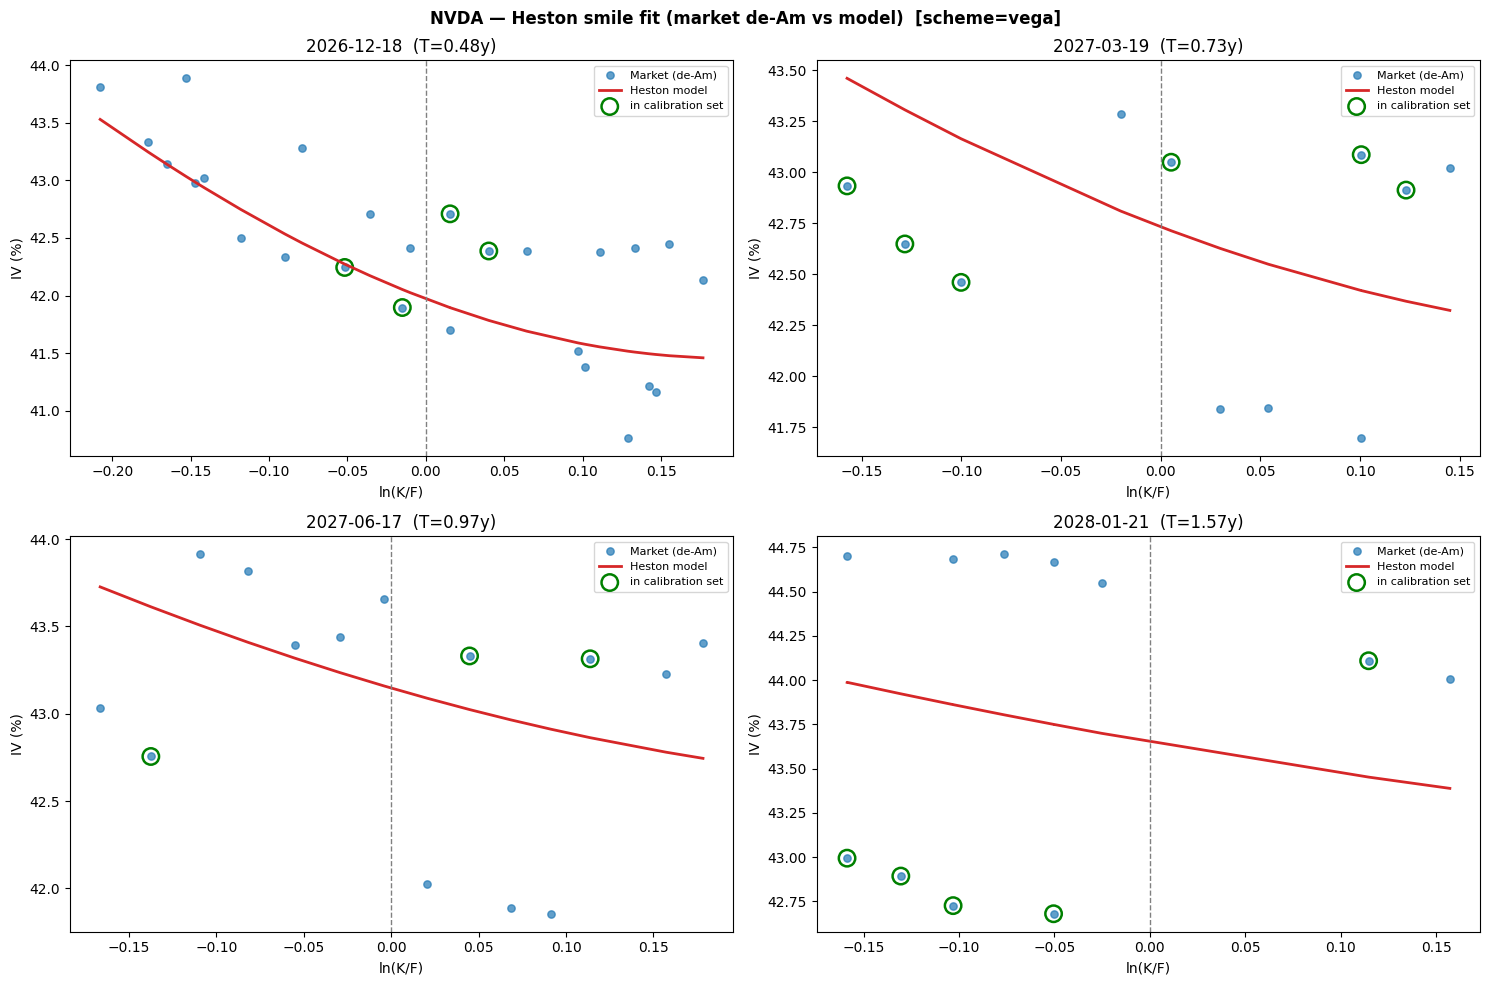

In [67]:
# Helper columns
lm_col = 'forward_moneyness' if 'forward_moneyness' in df.columns else 'moneyness'
df['log_fm'] = np.log(df[lm_col].where(df[lm_col] > 0))
cal_keys = set(zip(cal_df['maturity'], cal_df['type'], cal_df['strike'].round(4)))
df['in_cal'] = [ (m, t, round(k, 4)) in cal_keys
                 for m, t, k in zip(df['maturity'], df['type'], df['strike']) ]

# Pick the expiries with the most calibration coverage for the smile panels.
top_exp = (cal_df['maturity'].value_counts().head(4).index.tolist()
           if len(cal_df) else sorted(df['maturity'].unique())[:4])
top_exp = sorted(top_exp, key=lambda m: df.loc[df['maturity'] == m, 'T'].iloc[0])

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(f'{TICKER} — Heston smile fit (market de-Am vs model)  [scheme={WEIGHT_SCHEME}]',
             fontweight='bold')
for ax, mat in zip(axes.ravel(), top_exp):
    s = df[(df['maturity'] == mat) & df['market_iv'].notna() & df['model_iv'].notna()
           & (df['market_iv'] > 0.05)].sort_values('log_fm')
    if s.empty:
        ax.set_visible(False)
        continue
    Tval = s['T'].iloc[0]
    ax.scatter(s['log_fm'], s['market_iv']*100, s=28, c='#1f77b4', alpha=0.7, label='Market (de-Am)')
    ax.plot(s['log_fm'], s['model_iv']*100, '-', color='#d62728', lw=2, label='Heston model')
    cal = s[s['in_cal']]
    if not cal.empty:
        ax.scatter(cal['log_fm'], cal['market_iv']*100, s=140, facecolors='none',
                   edgecolors='green', linewidths=1.8, label='in calibration set')
    ax.axvline(0, color='gray', ls='--', lw=1)
    ax.set_title(f'{mat}  (T={Tval:.2f}y)')
    ax.set_xlabel('ln(K/F)'); ax.set_ylabel('IV (%)'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

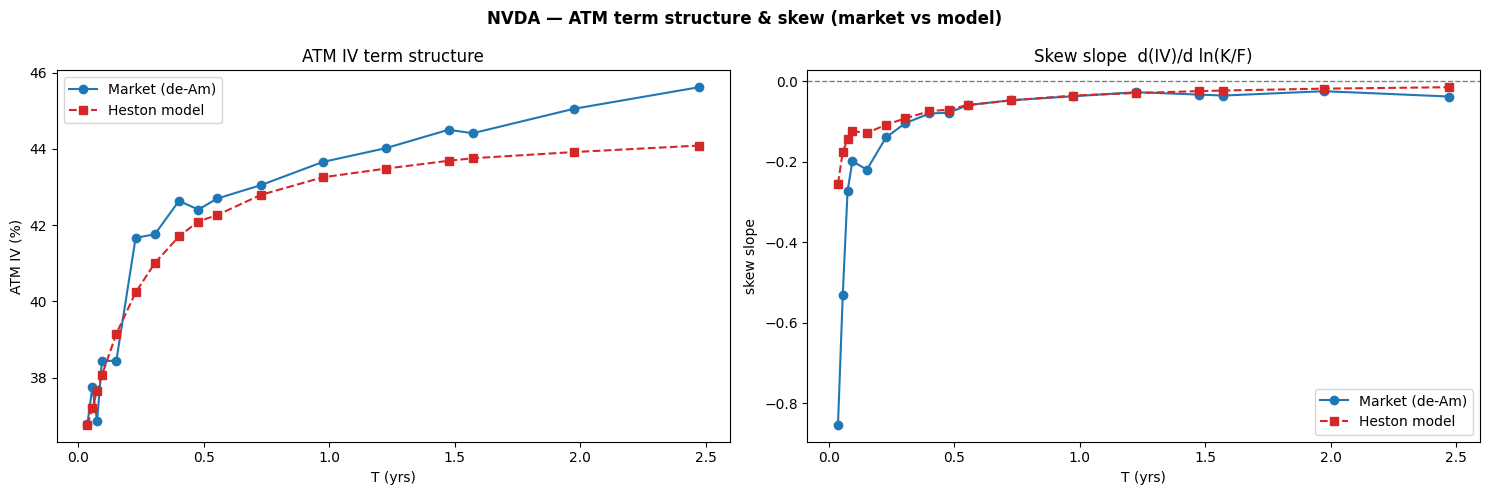

  maturity      T  mkt_atm  mdl_atm  mkt_skew  mdl_skew
2026-07-10 0.0371   0.3680   0.3676   -0.8538   -0.2553
2026-07-17 0.0562   0.3775   0.3721   -0.5301   -0.1754
2026-07-24 0.0754   0.3687   0.3765   -0.2722   -0.1450
2026-07-31 0.0946   0.3843   0.3807   -0.1992   -0.1243
2026-08-21 0.1521   0.3845   0.3915   -0.2201   -0.1289
2026-09-18 0.2289   0.4167   0.4024   -0.1396   -0.1085
2026-10-16 0.3056   0.4176   0.4101   -0.1046   -0.0926
2026-11-20 0.4015   0.4264   0.4170   -0.0806   -0.0748
2026-12-18 0.4782   0.4241   0.4210   -0.0785   -0.0710
2027-01-15 0.5549   0.4270   0.4227   -0.0598   -0.0594
2027-03-19 0.7275   0.4305   0.4279   -0.0475   -0.0481
2027-06-17 0.9741   0.4366   0.4326   -0.0378   -0.0360
2027-09-17 1.2261   0.4402   0.4348   -0.0276   -0.0297
2027-12-17 1.4754   0.4450   0.4369   -0.0337   -0.0250
2028-01-21 1.5713   0.4441   0.4376   -0.0360   -0.0235
2028-06-16 1.9741   0.4505   0.4392   -0.0252   -0.0188
2028-12-15 2.4727   0.4562   0.4409   -0.0384   

In [33]:
# ATM term structure + skew slope by maturity
def atm_iv(group, col):
    g = group.dropna(subset=[col])
    if g.empty:
        return np.nan
    return g.loc[g['log_fm'].abs().idxmin(), col]

def skew_slope(group, col):
    # d(IV)/d(ln K/F) via least-squares over the available strikes (the 25d-ish skew sign).
    g = group.dropna(subset=[col, 'log_fm'])
    g = g[(g[col] > 0.05)]
    if len(g) < 3:
        return np.nan
    return float(np.polyfit(g['log_fm'], g[col], 1)[0])

term = []
for mat, g in df.groupby('maturity'):
    term.append({'maturity': mat, 'T': g['T'].iloc[0],
                 'mkt_atm': atm_iv(g, 'market_iv'), 'mdl_atm': atm_iv(g, 'model_iv'),
                 'mkt_skew': skew_slope(g, 'market_iv'), 'mdl_skew': skew_slope(g, 'model_iv')})
term = pd.DataFrame(term).sort_values('T')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(f'{TICKER} — ATM term structure & skew (market vs model)', fontweight='bold')
axes[0].plot(term['T'], term['mkt_atm']*100, 'o-', label='Market (de-Am)', color='#1f77b4')
axes[0].plot(term['T'], term['mdl_atm']*100, 's--', label='Heston model', color='#d62728')
axes[0].set_title('ATM IV term structure'); axes[0].set_xlabel('T (yrs)')
axes[0].set_ylabel('ATM IV (%)'); axes[0].legend()
axes[1].plot(term['T'], term['mkt_skew'], 'o-', label='Market (de-Am)', color='#1f77b4')
axes[1].plot(term['T'], term['mdl_skew'], 's--', label='Heston model', color='#d62728')
axes[1].axhline(0, color='gray', ls='--', lw=1)
axes[1].set_title('Skew slope  d(IV)/d ln(K/F)'); axes[1].set_xlabel('T (yrs)')
axes[1].set_ylabel('skew slope'); axes[1].legend()
plt.tight_layout(); plt.show()
print(term.to_string(index=False))

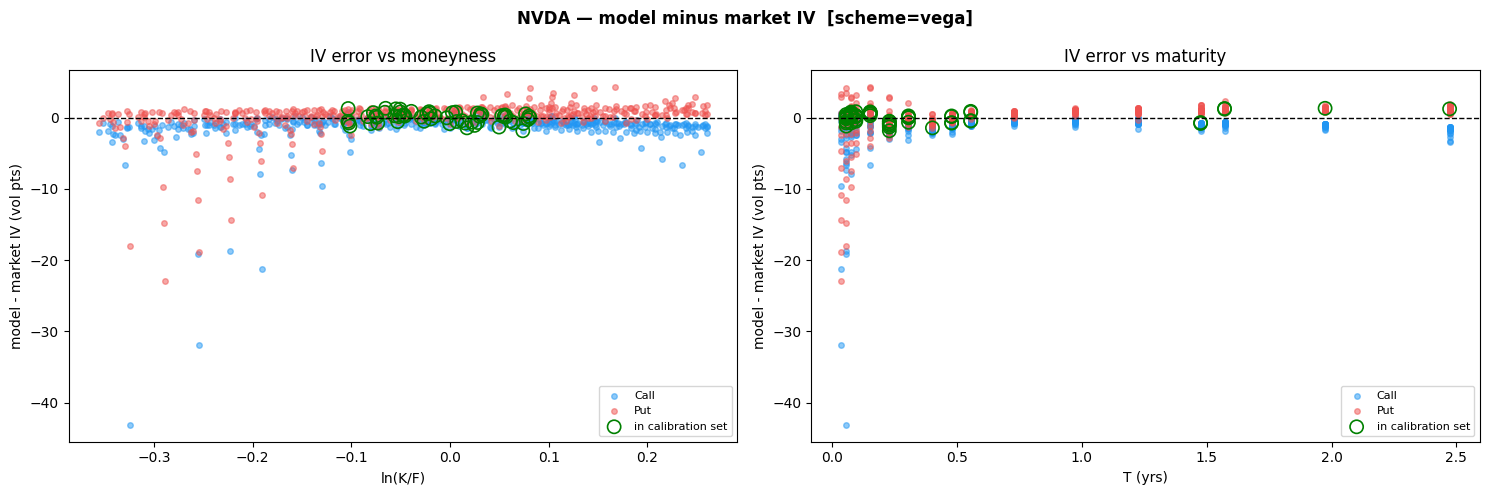

In [34]:
# IV error vs moneyness and maturity (where does the fit miss?)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(f'{TICKER} — model minus market IV  [scheme={WEIGHT_SCHEME}]', fontweight='bold')
for ax, x, xl in [(axes[0], 'log_fm', 'ln(K/F)'), (axes[1], 'T', 'T (yrs)')]:
    for typ, c in [('call', '#2196F3'), ('put', '#EF5350')]:
        s = df[df['type'] == typ]
        ax.scatter(s[x], s['iv_error']*100, s=16, alpha=0.5, color=c, label=typ.capitalize())
    cal_mask = df['in_cal']
    ax.scatter(df.loc[cal_mask, x], df.loc[cal_mask, 'iv_error']*100, s=90,
               facecolors='none', edgecolors='green', linewidths=1.2, label='in calibration set')
    ax.axhline(0, color='black', lw=1, ls='--'); ax.set_xlabel(xl)
    ax.set_ylabel('model - market IV (vol pts)'); ax.legend(fontsize=8)
axes[0].set_title('IV error vs moneyness'); axes[1].set_title('IV error vs maturity')
plt.tight_layout(); plt.show()

## Summary

In [35]:
print('=' * 64)
print(f'  {TICKER} OTM-ONLY HESTON CALIBRATION  (experiment)')
print('=' * 64)
print(f'  Spot ${SPOT:.2f} | div {Q*100:.3f}% | rate {curve_summary(rate_curve)}')
print(f'  Universes: pricing {len(pricing_df)}  |  calibration {len(cal_df)} '
      f'({n_put} OTM puts + {n_call} OTM calls)')
print(f'  Calibration: weight={WEIGHT_SCHEME}  feller_w={FELLER_WEIGHT}  de-Am={CAL_DE_AMERICANIZE}')
print()
print(f'    v0={p.v0:.4f}  kappa={p.kappa:.4f}  theta={p.theta:.4f}  '
      f'sigma={p.sigma:.4f}  rho={p.rho:+.4f}')
print(f'    Feller {feller:+.4f} ({"ok" if feller > 0 else "violated"}) | '
      f'weighted loss {loss:.3e} | {runtime:.1f}s')
print()
print(f'  Pricing accuracy (broad universe):')
print(f'    MAE ${df["abs_error"].mean():.4f} | mean |IV err| {df["iv_error"].abs().mean()*100:.2f} vpts')
print('=' * 64)

  NVDA OTM-ONLY HESTON CALIBRATION  (experiment)
  Spot $192.56 | div 0.145% | rate 3M: 3.67%  |  5Y: 4.13%  |  10Y: 4.38%
  Universes: pricing 869  |  calibration 57 (31 OTM puts + 26 OTM calls)
  Calibration: weight=vega  feller_w=0.0  de-Am=True

    v0=0.1311  kappa=10.0000  theta=0.2035  sigma=1.7014  rho=-0.2081
    Feller +1.1762 (ok) | weighted loss 1.049e+00 | 0.4s

  Pricing accuracy (broad universe):
    MAE $0.4898 | mean |IV err| 1.34 vpts
